# Package Installation and Imports


*   Install required packages and import libraries for deep learning, data processing, and visualization.

*   Sets up the computing device (GPU if available, otherwise CPU)



In [1]:
!pip install -q -U fast_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import torch
import transformers
import plotly.express as px
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer, AutoModelForSequenceClassification
from fast_ml.model_development import train_valid_test_split
import shutil

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


#Evaluation Metrics Function
* Define a function to calculate classification performance metrics

* Returns F1 score, precision, recall, balanced accuracy, and confusion matrix plot
* Uses macro averaging to treat all classes equally regardless of their frequency

In [4]:
from sklearn.metrics import f1_score, precision_score, recall_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
def scores(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    return {
        "f1 score": f1_score(y_test, y_pred, average="macro"),
        "precision": precision_score(y_test, y_pred, average="macro"),
        "recall": recall_score(y_test, y_pred, average="macro"),
        "accuracy": balanced_accuracy_score(y_test, y_pred),
        "plot": disp.plot(),
    }

# Load dataset
* Load the Twitter dataset and perform initial data cleaning
* Remove duplicate tweets, calculate text length, convert verification status to boolean


In [5]:
path = "."

In [6]:
reduced_path = os.path.join(path, "reducedDataset")
# Clean/create output directory
shutil.rmtree(reduced_path, ignore_errors=True)
os.makedirs(reduced_path)
file_name = os.path.join(path, "all.csv")

tweets_df = pd.read_csv(file_name)

In [7]:
tweets_df.drop_duplicates(subset="Text", inplace=True)

In [8]:
tweets_df["text_len"] = tweets_df["Text"].apply(len)
tweets_df["verified"] = tweets_df["User Verified"].astype(bool)

# Dataset Labelling -  Virality Classification
* Create virality classes based on retweet counts using predefined thresholds
* RT_THRESHOLDS = [0, 1, 20] creates 4 classes: ≤0, ≤1, ≤20, >20 retweets


In [9]:
RT_THRESHOLDS = [0, 1, 20] # virality classes - change to use other thresholds
def vir_transform(rt, th=RT_THRESHOLDS):
    # take rt number and return virality class
    for i, t in enumerate(th):
        if rt <= t:
            return i
    return len(th)

In [10]:
tweets_df["virality"] = tweets_df["Retweets"].apply(vir_transform)

Histogram for RT counts in each class




In [11]:
counts, bins = np.histogram(tweets_df.virality, bins=len(RT_THRESHOLDS)+1)
fig = px.bar(x=[str(i) for i in range(len(RT_THRESHOLDS) + 1)], y=counts, labels={"x": "Virality", "y": "Count"},)
fig.show()

# Data loader - From original viralBert paper

In [12]:
class Loader():
    def __init__(self, features, labels, batch_size=32, target_size=len(RT_THRESHOLDS) + 1):
        self.batch_size = batch_size
        self.features = features
        self.labels = labels
        self.batches = len(self.labels) // self.batch_size
        self.index = -1
        self.target_size = target_size

    def __len__(self):
        return self.batches

    def __iter__(self):
        self.index = -1
        return self

    def _ohe(self, lbls):
        ohe = torch.zeros((lbls.size, self.target_size))
        ohe[torch.arange(lbls.size), lbls.values] = 1
        return ohe

    def __next__(self):
        self.index += 1
        if self.index >= self.batches:
            raise StopIteration
        start = self.index * self.batch_size
        end = (self.index + 1) * self.batch_size
        return self.features[start:end], self._ohe(self.labels[start:end])

# Baseline Models - From original viralBert paper

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train, X_test, y_train, y_test = train_test_split(
    scaler.fit_transform(tweets_df[["Hashtags Count", "Reply Count", "User Verified", "User Followers", "User Following", "text_len"]]),
    tweets_df[["virality"]],
    random_state=42,
)

In [14]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

In [15]:
def fit(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, np.ravel(y_train))
    y_pred = model.predict(X_test)
    return scores(y_test, y_pred)

Logistic Regression

{'f1 score': 0.22033622102991474,
 'precision': 0.39993388022300425,
 'recall': 0.2765178203866898,
 'accuracy': np.float64(0.2765178203866898),
 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x7978b133ec50>}

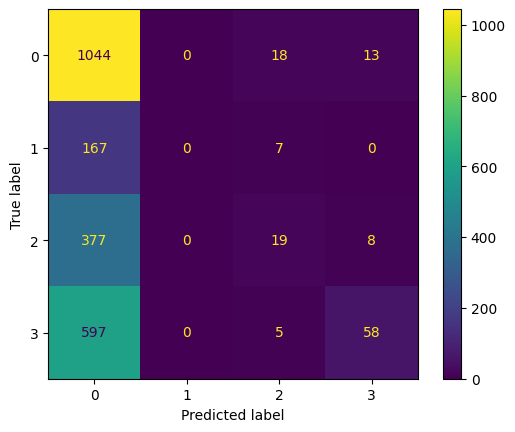

In [16]:
fit(LogisticRegression(solver="newton-cg"), X_train, y_train, X_test, y_test)

SVM (with SGD)

{'f1 score': 0.20913780561941342,
 'precision': 0.5229079793354845,
 'recall': 0.2713417999779128,
 'accuracy': np.float64(0.2713417999779128),
 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x7978b0bcf790>}

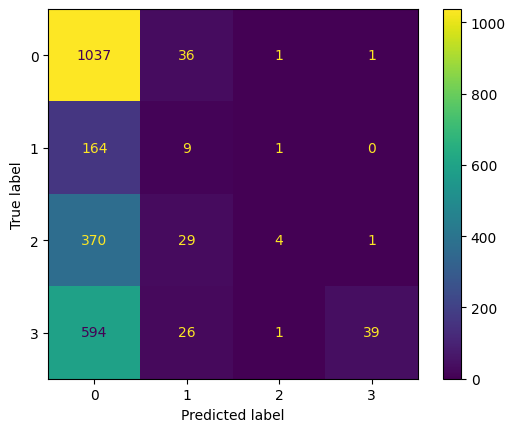

In [17]:
fit(SGDClassifier(), X_train, y_train, X_test, y_test)

Decision Tree

{'f1 score': 0.45413751203057984,
 'precision': 0.45479193318395483,
 'recall': 0.45417763989710924,
 'accuracy': np.float64(0.45417763989710924),
 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x7978b0c7f550>}

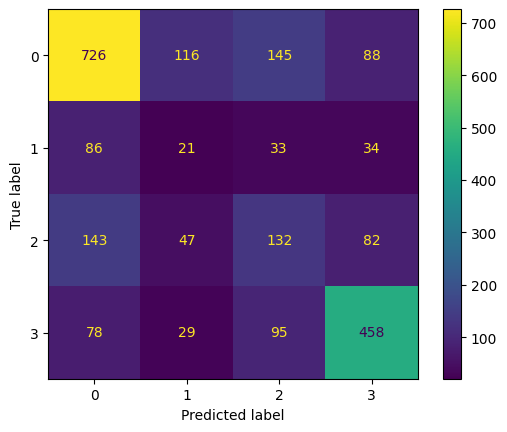

In [18]:
fit(tree.DecisionTreeClassifier(), X_train, y_train, X_test, y_test)

Random Forest

{'f1 score': 0.48157635988020886,
 'precision': 0.5072859597204565,
 'recall': 0.48419127778856474,
 'accuracy': np.float64(0.48419127778856474),
 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x7978b0a9d290>}

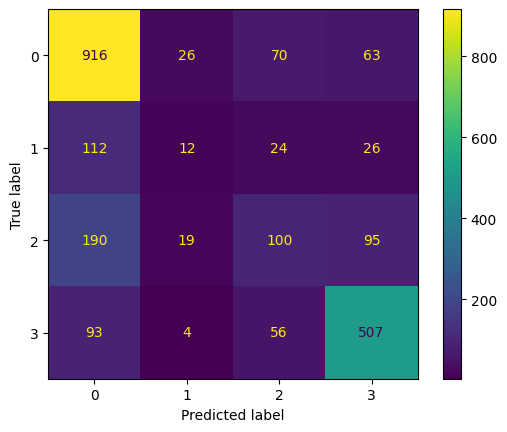

In [19]:
fit(RandomForestClassifier(random_state=0), X_train, y_train, X_test, y_test)

#DL Models

## Original Paper ViralBERT Data prep

**Label Encoding** Converts the categorical virality column into numeric labels using LabelEncoder.

**Feature Selection & Cleaning:** Selects the columns listed in input_feats from tweets_df and removes any rows with missing values.

**Shuffling**: Randomly shuffles the rows to eliminate any ordering bias.

In [20]:
input_feats = ["Text", "Hashtags Count", "Reply Count", "User Followers", "User Following", "User Verified", "text_len", ]


In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df = tweets_df.loc[:, input_feats].dropna()
df["virality"] = le.fit_transform(tweets_df["virality"])
df = df.sample(frac=1, random_state=42)
df.head()
#df.info()

,Text,Hashtags Count,Reply Count,User Followers,User Following,User Verified,text_len,virality
631,"NJZ performing their smash hit ""super shy"" at ...",0,12,3137,21,False,123,3
4345,Come stream with Meg! 💜,0,0,114,303,False,24,2
9944,missing his onigiri 💔BRING IT BACK NOW THE NEW...,0,0,454,454,False,113,1
5903,The BTS VS ...,0,11,1155,1190,False,84,3
5239,bigbang AND seventeen possibly going on tour??...,0,1,1998,840,False,59,0


# Original Scaling numeric feats
Normalize selected numeric `features` to a 0–1 range using MinMaxScaler.
This helps machine learning models perform better by putting all features on the same scale.
We apply it to features like counts and lengths that have different value ranges.

**TODO**: Test whether log-scaling 'User Followers' improves model performance


In [22]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()
numeric_feats_to_scale = ["Hashtags Count", "Reply Count", "User Following", "User Verified", "text_len"]
df[numeric_feats_to_scale] = scaler.fit_transform(df[numeric_feats_to_scale])



# Train/Validation/Test Split



In [23]:
(train_features, train_labels,
 val_features, val_labels,
 test_features, test_labels) = train_valid_test_split(df, target = 'virality', train_size=0.8, valid_size=0.1, test_size=0.1, random_state=42)

In [24]:
train_loader = Loader(train_features, train_labels)
val_loader = Loader(val_features, val_labels)
test_loader = Loader(test_features, test_labels)

#Text Tokenization Setup
* Load BERTweet model and tokenizer for processing Twitter text
* BERTweet is specifically pre-trained on Twitter data
* Define encode function to convert text to token IDs and attention masks
* Sets maximum sequence length to 128 tokens with padding/truncation

In [25]:
bert = AutoModel.from_pretrained("vinai/bertweet-base")
tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base", use_fast=True, normalization=True)

def encode(df, tokenizer=tokenizer, inp="Text"):
    text = df[inp]
    inputs = tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True,
            max_length=128,
            truncation=True,
            padding='max_length',
            return_token_type_ids=False,
        )
    ids = inputs['input_ids']
    mask = inputs['attention_mask']
    return torch.tensor(ids, dtype=torch.long), torch.tensor(mask, dtype=torch.long)

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


#Loss Function

In [26]:
w = [len(train_labels[train_labels == i])/len(train_labels) for i in range(len(RT_THRESHOLDS) + 1)]
weights = torch.tensor(w, dtype=torch.float).to(device)

In [27]:
# From https://github.com/vandit15/Class-balanced-loss-pytorch.git
def focal_loss(logits, labels, alpha=weights, gamma=2.0):
    """Compute the focal loss between `logits` and the ground truth `labels`.
    Focal loss = -alpha_t * (1-pt)^gamma * log(pt)
    where pt is the probability of being classified to the true class.
    pt = p (if true class), otherwise pt = 1 - p. p = sigmoid(logit).
    Args:
      labels: A float tensor of size [batch, num_classes].
      logits: A float tensor of size [batch, num_classes].
      alpha: A float tensor of size [batch_size]
        specifying per-example weight for balanced cross entropy.
      gamma: A float scalar modulating loss from hard and easy examples.
    Returns:
      focal_loss: A float32 scalar representing normalized total loss.
    """
    BCLoss = F.binary_cross_entropy_with_logits(input = logits, target = labels,reduction = "none")

    if gamma == 0.0:
        modulator = 1.0
    else:
        modulator = torch.exp(-gamma * labels * logits - gamma * torch.log(1 +
            torch.exp(-1.0 * logits)))

    loss = modulator * BCLoss

    weighted_loss = alpha * loss
    focal_loss = torch.sum(weighted_loss)

    focal_loss /= torch.sum(labels)
    return focal_loss

criterion = focal_loss

In [28]:
sm = nn.Softmax()

## Train Val Test functions
* Define training, validation, and testing functions for the neural network
* Each function handles:

 Text encoding and batch padding

 Moving tensors to GPU/CPU

 Forward pass through model

 Loss calculation and backpropagation (training only)

 Metric calculation and logging

In [29]:
# Assuming the encode function returns a tuple of (input_ids, attention_mask)
import torch.nn.utils.rnn as rnn_utils

def train(model, arg_function, epoch, print_every=500, inp="Text"):
    model.train()
    losses = []
    for i, (inputs, targets) in enumerate(train_loader):
        optimizer.zero_grad()

        # Encode text and apply padding
        encoded_inputs = inputs.loc[:, [inp]].apply(encode, inp=inp, axis=1, result_type="expand")
        input_ids = [item[0].squeeze(0) for item in encoded_inputs.values] # Squeeze to remove extra dimension if present
        attention_masks = [item[1].squeeze(0) for item in encoded_inputs.values] # Squeeze to remove extra dimension if present

        # Pad sequences to the maximum length in the batch
        input_ids = rnn_utils.pad_sequence(input_ids, batch_first=True, padding_value=0)
        attention_masks = rnn_utils.pad_sequence(attention_masks, batch_first=True, padding_value=0)

        # Move tensors to device
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        targets = targets.to(device)

        # Get additional features
        kwargs = arg_function(inputs)
        kwargs['input_ids'] = input_ids
        kwargs['attention_mask'] = attention_masks

        outputs = model(**kwargs)
        loss = criterion(outputs, targets)
        losses.append(loss.item())

        if i % print_every == 0:
            print(f'Epoch: {epoch}, i: {i}, Loss:  {torch.mean(torch.tensor(losses)).item()}')
            losses = []

        loss.backward()
        optimizer.step()


# Assuming the encode function returns a tuple of (input_ids, attention_mask)
def validate(model, arg_function, inp="Text"):
    model.eval()
    total_loss = []
    all_y = []
    all_y_pred = []
    with torch.no_grad():
        for i, (inputs, targets) in enumerate(val_loader):
             # Encode text and apply padding
            encoded_inputs = inputs.loc[:, [inp]].apply(encode, inp=inp, axis=1, result_type="expand")
            input_ids = [item[0].squeeze(0) for item in encoded_inputs.values] # Squeeze to remove extra dimension if present
            attention_masks = [item[1].squeeze(0) for item in encoded_inputs.values] # Squeeze to remove extra dimension if present

            # Pad sequences to the maximum length in the batch
            input_ids = rnn_utils.pad_sequence(input_ids, batch_first=True, padding_value=0)
            attention_masks = rnn_utils.pad_sequence(attention_masks, batch_first=True, padding_value=0)

            # Move tensors to device
            input_ids = input_ids.to(device)
            attention_masks = attention_masks.to(device)
            targets = targets.to(device)

            # Get additional features
            kwargs = arg_function(inputs)
            kwargs['input_ids'] = input_ids
            kwargs['attention_mask'] = attention_masks

            outputs = model(**kwargs)
            loss = criterion(outputs, targets)
            y_pred = sm(outputs)
            y_pred = torch.zeros(y_pred.shape).to(device).scatter(1, y_pred.argmax(1).unsqueeze(1), 1).cpu().detach().numpy()
            y = targets.cpu().detach().numpy()
            all_y.append(y.argmax(1))
            all_y_pred.append(y_pred.argmax(1))
            total_loss.append(loss.item())

    print("validation loss: ", torch.mean(torch.tensor(total_loss)).item())
    all_y = np.concatenate(all_y)
    all_y_pred = np.concatenate(all_y_pred)
    s = scores(all_y, all_y_pred)
    print(s)


# Assuming the encode function returns a tuple of (input_ids, attention_mask)
def test(model, arg_function, inp="Text"):
    model.eval()
    all_y = []
    all_y_pred = []
    with torch.no_grad():
        for i, (inputs, targets) in enumerate(test_loader):
            # Encode text and apply padding
            encoded_inputs = inputs.loc[:, [inp]].apply(encode, inp=inp, axis=1, result_type="expand")
            input_ids = [item[0].squeeze(0) for item in encoded_inputs.values] # Squeeze to remove extra dimension if present
            attention_masks = [item[1].squeeze(0) for item in encoded_inputs.values] # Squeeze to remove extra dimension if present

            # Pad sequences to the maximum length in the batch
            input_ids = rnn_utils.pad_sequence(input_ids, batch_first=True, padding_value=0)
            attention_masks = rnn_utils.pad_sequence(attention_masks, batch_first=True, padding_value=0)

            # Move tensors to device
            input_ids = input_ids.to(device)
            attention_masks = attention_masks.to(device)
            targets = targets.to(device)

            # Get additional features
            kwargs = arg_function(inputs)
            kwargs['input_ids'] = input_ids
            kwargs['attention_mask'] = attention_masks

            outputs = model(**kwargs)
            y_pred = sm(outputs)
            y_pred = torch.zeros(y_pred.shape).to(device).scatter(1, y_pred.argmax(1).unsqueeze(1), 1).cpu().detach().numpy()
            y = targets.cpu().detach().numpy()
            all_y.append(y.argmax(1))
            all_y_pred.append(y_pred.argmax(1))

    all_y = np.concatenate(all_y)
    all_y_pred = np.concatenate(all_y_pred)
    s = scores(all_y, all_y_pred)
    print(s)

# ViralBERT Data Preparation:
* Prepare input features for the ViralBERT model
* Combine text and numerical features into a single input string
* Select features: text, hashtag count, reply count, followers, following, verification, text length
* Convert all features to string format and join with periods

In [30]:
input_feats = ["Text", "Hashtags Count", "Reply Count", "User Followers", "User Following", "User Verified", "text_len", ]

In [31]:
df = tweets_df.loc[:, input_feats].dropna()
df.head()

,Text,Hashtags Count,Reply Count,User Followers,User Following,User Verified,text_len
0,Happy 34th birthday to IRENE of Red Velvet! ht...,0,198,677944,79,False,67
1,GDRAGON : THE KING OF KPOP https://t.co/HFwcVJ...,0,0,4687,1085,False,50
2,BTS’ V shares new pictures. https://t.co/uIu4a...,0,317,677944,79,False,51
3,THE BOYZ Eric https://t.co/1CAAcRONZ7,0,7,103067,414,False,37
4,Sullyoon (NMIXX) https://t.co/Z1LXRtY205,0,2,279649,492,False,40


In [32]:
def combine_feats(x):
    return ". ".join([str(val) for val in x.values])

In [33]:
df["input"] = df.apply(combine_feats, axis=1)

In [34]:
df["virality"] = le.fit_transform(tweets_df["virality"])

In [35]:
(train_features, train_labels,
 val_features, val_labels,
 test_features, test_labels) = train_valid_test_split(df, target = 'virality', train_size=0.8, valid_size=0.1, test_size=0.1, random_state=42)

In [36]:
train_loader = Loader(train_features, train_labels)
val_loader = Loader(val_features, val_labels)
test_loader = Loader(test_features, test_labels)

# Text Preprocessing Function
* Define preprocessing function for Twitter text
* Replace usernames with '@user' token and URLs with 'http' token
* This standardization helps the model focus on content rather than specific users/links

In [37]:
def preprocess(text):
    new_text = []
    for t in text.split(" "):
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)

# Load sentiment analysis model (RoBERTa) and BERTweet model

In [38]:
sent_tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")

sent_model = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [39]:
bert = AutoModel.from_pretrained("vinai/bertweet-base")

tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base", use_fast=True, normalization=True)

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


#Model 1: Original viralBERT architecture
* BERTweet for text understanding
* RoBERTa for sentiment analysis
* Fully connected layers for classification

Basicly concatenates BERTweet and sentiment features for final prediction

In [40]:
class Arch(nn.Module):
    def __init__(self, bert, sentiment_model):
        super(Arch, self).__init__()
        self.bert = bert
        self.sent = sentiment_model
        self.pre_classifier = nn.Linear(771, 771)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(771, 4)

    def forward(self, input_ids, attention_mask, sent_input_ids, sent_attention_mask):
        output_1 = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = output_1[0]
        sent_output = self.sent(input_ids=sent_input_ids, attention_mask=sent_attention_mask)
        pooler = torch.cat((hidden_state[:, 0], sent_output[0]), 1)
        pooler = self.pre_classifier(pooler)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout(pooler)
        output = self.classifier(pooler)
        return output

Training Setup - as in original paper:
* Initialize the ViralBERT model and optimizer
* Use AdamW optimizer with learning rate 1e-5
* Define argument function to preprocess text and get sentiment features


In [41]:
import torch
import torch.nn as nn
import transformers
from torch.optim import AdamW

model1 = Arch(bert, sent_model).to(device)
optimizer = AdamW(params=model1.parameters(), lr=1e-5)

In [42]:
def arg_func(x):
    clean_text = [preprocess(t) for t in x["Text"].values]
    encoded = sent_tokenizer(clean_text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    sent_input_ids = encoded["input_ids"].to(device)
    sent_attention_mask = encoded["attention_mask"].to(device)

    return {"sent_input_ids": sent_input_ids, "sent_attention_mask": sent_attention_mask}

ViralBERT Model training - Original paper and my data:
* Train the ViralBERT model for 3 epochs
* Each epoch includes training and validation phases
* Save the trained model weights to disk for later us

Epoch: 0, i: 0, Loss:  0.1802457869052887
validation loss:  0.10189733654260635
{'f1 score': 0.39775373173551987, 'precision': 0.44604492959974684, 'recall': 0.44337307929540937, 'accuracy': np.float64(0.44337307929540937), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x79782b5f9d90>}
Epoch: 1, i: 0, Loss:  0.09635212272405624
validation loss:  0.09715856611728668
{'f1 score': 0.4548602785516921, 'precision': 0.47389689912557736, 'recall': 0.4758638271987787, 'accuracy': np.float64(0.4758638271987787), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x79783262d110>}
Epoch: 2, i: 0, Loss:  0.0877319872379303
validation loss:  0.09857475757598877
{'f1 score': 0.47664171983650705, 'precision': 0.4812727060607829, 'recall': 0.49091552307571723, 'accuracy': np.float64(0.49091552307571723), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x7978333b5e90>}


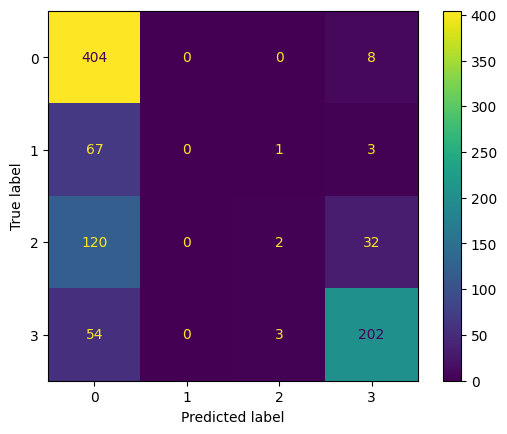

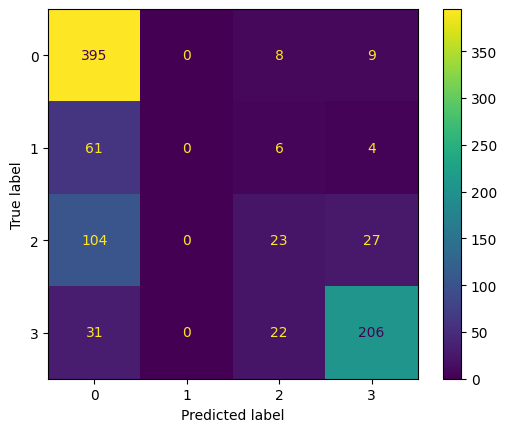

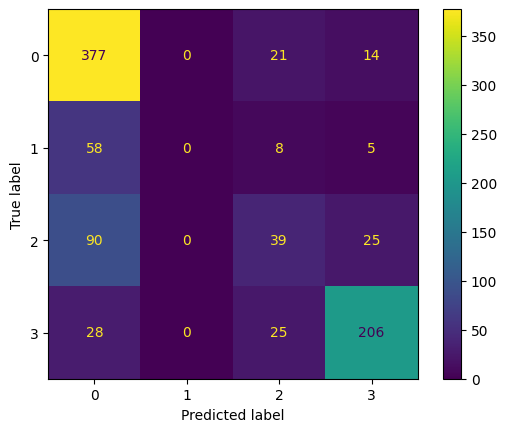

In [43]:
for epoch in range(3):
    train(model1, arg_func, epoch, inp="input")
    validate(model1, arg_func, inp="input")

In [44]:
os.makedirs("./models", exist_ok=True)

torch.save(model1.state_dict(), "./models/vb.pt")

ViralBERT Model testing - Original paper and my data:


In [45]:
model1 = Arch(bert, sent_model).to(device)
model1.load_state_dict(torch.load("./models/vb.pt"))

<All keys matched successfully>

{'f1 score': 0.4773681108163867, 'precision': 0.4848324514991182, 'recall': 0.48962308245194797, 'accuracy': np.float64(0.48962308245194797), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x79782b5ed9d0>}


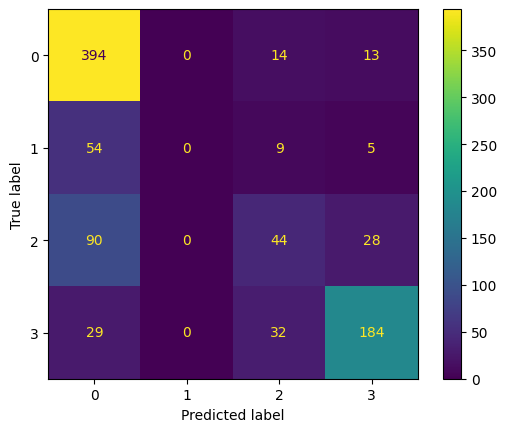

In [46]:
test(model1, arg_func, inp="input")

#Model 2: CNN-Enhanced ViralBERT:


Epoch: 0, i: 0, Loss:  0.17153319716453552
validation loss:  0.10986503213644028
{'f1 score': 0.4807796292110773, 'precision': 0.47131635844450487, 'recall': 0.4962625278159259, 'accuracy': np.float64(0.4962625278159259), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x79782042f410>}
Epoch: 1, i: 0, Loss:  0.06154446676373482
validation loss:  0.13985814154148102
{'f1 score': 0.47824734081889064, 'precision': 0.47900026255141626, 'recall': 0.49983046342269644, 'accuracy': np.float64(0.49983046342269644), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x79782046f190>}
Epoch: 2, i: 0, Loss:  0.049002498388290405
validation loss:  0.15843136608600616
{'f1 score': 0.4657216393420184, 'precision': 0.4590643242029636, 'recall': 0.4850520281345524, 'accuracy': np.float64(0.4850520281345524), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x7978326623d0>}
--------------------------Testing----

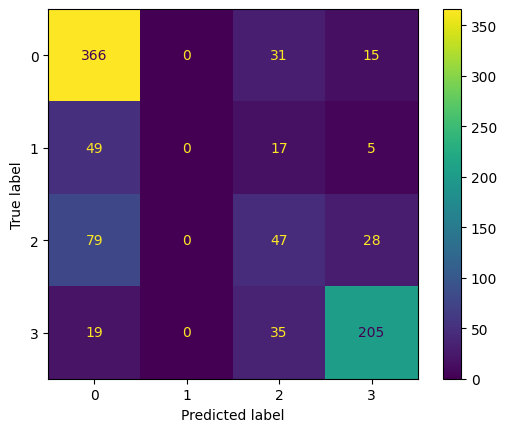

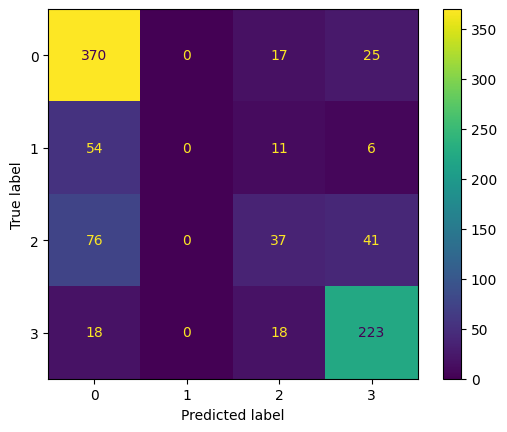

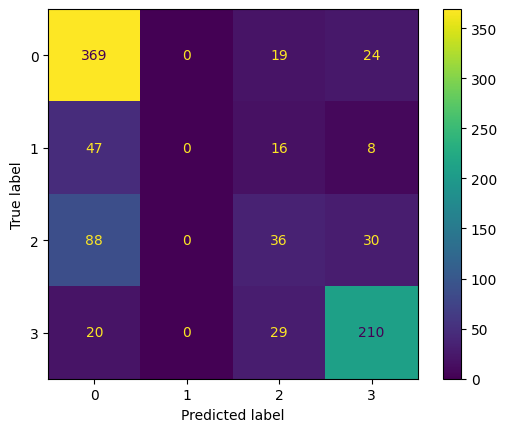

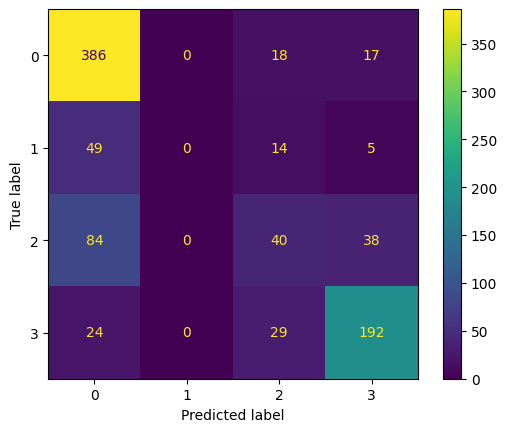

In [48]:
# Model 2
class Arch(nn.Module):
    def __init__(self, bert, sentiment_model):
        super(Arch, self).__init__()
        self.bert = bert
        self.sent = sentiment_model

        # CNN layers replacing the original MLP
        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.1)

        # Calculate size after convolutions: 771 -> 385 (after first pool) -> 192 (after second pool)
        # So final size is 192 * 32 = 6144
        self.fc = nn.Linear(6144, 771)  # Back to original size

        # Keep original ViralBERT structure
        self.pre_classifier = nn.Linear(771, 771)
        self.classifier = nn.Linear(771, 4)

    def forward(self, input_ids, attention_mask, sent_input_ids, sent_attention_mask):
        output_1 = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = output_1[0]
        sent_output = self.sent(input_ids=sent_input_ids, attention_mask=sent_attention_mask)
        pooler = torch.cat((hidden_state[:, 0], sent_output[0]), 1)

        # CNN processing instead of direct pre_classifier
        x = pooler.unsqueeze(1)  # Add channel dimension: [batch, 1, 771]
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)

        # Flatten and pass through FC to match original pre_classifier input
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        # Original ViralBERT final layers
        pooler = self.pre_classifier(x)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout(pooler)
        output = self.classifier(pooler)
        return output

import torch
import torch.nn as nn
import transformers
from torch.optim import AdamW

model2 = Arch(bert, sent_model).to(device)
optimizer = AdamW(params=model2.parameters(), lr=1e-5)

def arg_func(x):
    clean_text = [preprocess(t) for t in x["Text"].values]
    encoded = sent_tokenizer(clean_text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    sent_input_ids = encoded["input_ids"].to(device)
    sent_attention_mask = encoded["attention_mask"].to(device)

    return {"sent_input_ids": sent_input_ids, "sent_attention_mask": sent_attention_mask}

# Train
for epoch in range(3):
    train(model2, arg_func, epoch, inp="input")
    validate(model2, arg_func, inp="input")

os.makedirs("./models", exist_ok=True)
torch.save(model2.state_dict(), "./models/model2.pt")


# Test
print("--------------------------Testing-----------------------")
model2 = Arch(bert, sent_model).to(device)
model2.load_state_dict(torch.load("./models/model2.pt"))

test(model2, arg_func, inp="input")

# Model 3: CNN Classifier Replacement




Epoch: 0, i: 0, Loss:  0.1704508662223816
validation loss:  0.11397858709096909
{'f1 score': 0.44054461522179406, 'precision': 0.4621124239395818, 'recall': 0.469152649371096, 'accuracy': np.float64(0.469152649371096), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x79782bccc4d0>}
Epoch: 1, i: 0, Loss:  0.08461195230484009
validation loss:  0.135214164853096
{'f1 score': 0.48287694753789856, 'precision': 0.4861564978202608, 'recall': 0.5016947268160861, 'accuracy': np.float64(0.5016947268160861), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x79782a10bbd0>}
Epoch: 2, i: 0, Loss:  0.03679581359028816
validation loss:  0.15299107134342194
{'f1 score': 0.48390448109573964, 'precision': 0.48190381849891384, 'recall': 0.5009347940173183, 'accuracy': np.float64(0.5009347940173183), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x7978323118d0>}
--------------------------Testing-----------

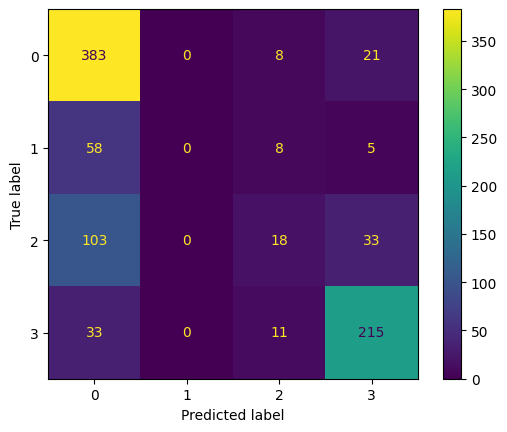

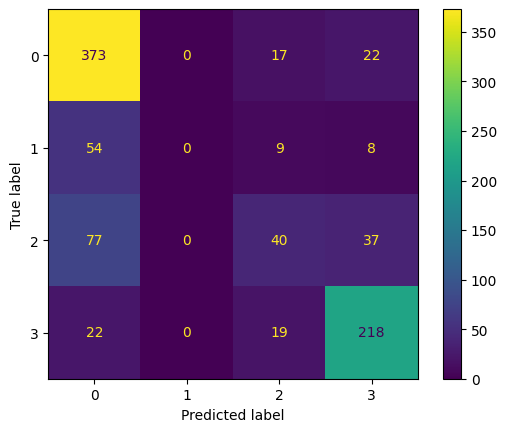

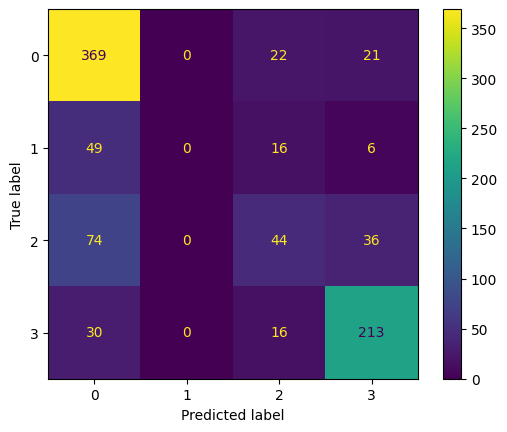

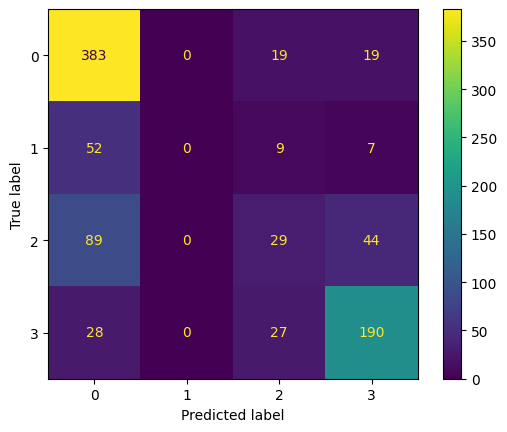

In [49]:
class Arch(nn.Module):
    def __init__(self, bert, sentiment_model):
        super(Arch, self).__init__()
        self.bert = bert
        self.sent = sentiment_model

        # Keep ViralBERT's original feature processing
        self.pre_classifier = nn.Linear(771, 771)
        self.dropout = nn.Dropout(0.1)

        # CNN layers REPLACING the final classifier (following CNN-IndoBERT approach)
        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)

        # Calculate size after convolutions: 771 -> 385 (after first pool) -> 192 (after second pool)
        # Final size: 192 * 32 = 6144
        self.cnn_classifier = nn.Linear(6144, 4)  # Direct to output classes

    def forward(self, input_ids, attention_mask, sent_input_ids, sent_attention_mask):
        # Original ViralBERT feature extraction (unchanged)
        output_1 = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = output_1[0]
        sent_output = self.sent(input_ids=sent_input_ids, attention_mask=sent_attention_mask)
        pooler = torch.cat((hidden_state[:, 0], sent_output[0]), 1)

        # ViralBERT's pre-processing (unchanged)
        pooler = self.pre_classifier(pooler)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout(pooler)

        #  apply CNN as final classifier (following CNN-IndoBERT)
        x = pooler.unsqueeze(1)  # Add channel dimension: [batch, 1, 771]
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)

        # Flatten and classify directly
        x = x.view(x.size(0), -1)
        output = self.cnn_classifier(x)  # Direct classification

        return output

import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from torch.optim import AdamW

model3 = Arch(bert, sent_model).to(device)
optimizer = AdamW(params=model3.parameters(), lr=1e-5)

def arg_func(x):
    clean_text = [preprocess(t) for t in x["Text"].values]
    encoded = sent_tokenizer(clean_text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    sent_input_ids = encoded["input_ids"].to(device)
    sent_attention_mask = encoded["attention_mask"].to(device)

    return {"sent_input_ids": sent_input_ids, "sent_attention_mask": sent_attention_mask}

# Train
for epoch in range(3):
    train(model3, arg_func, epoch, inp="input")
    validate(model3, arg_func, inp="input")

os.makedirs("./models", exist_ok=True)
torch.save(model3.state_dict(), "./models/model3.pt")

# Test
print("--------------------------Testing-----------------------")
model3 = Arch(bert, sent_model).to(device)
model3.load_state_dict(torch.load("./models/model3.pt"))

test(model2, arg_func, inp="input")

# Model 4 - Advanced CNN-Enhanced ViralBERT with Skip Connections

Starting training with improved architecture...
Epoch: 0, Batch: 0, Loss: 0.1854, LR: 4.00e-07
validation loss:  0.15728966891765594
{'f1 score': 0.49335267067455385, 'precision': 0.5092059553349876, 'recall': 0.4848232395494121, 'accuracy': np.float64(0.4848232395494121), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x7978215882d0>}
Epoch: 1, Batch: 0, Loss: 0.0334, LR: 8.41e-06
validation loss:  0.15946796536445618
{'f1 score': 0.5145907896726829, 'precision': 0.515982200178396, 'recall': 0.5139149494663647, 'accuracy': np.float64(0.5139149494663647), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x79782155fed0>}
Epoch: 2, Batch: 0, Loss: 0.0192, LR: 3.00e-06
validation loss:  0.15603449940681458
{'f1 score': 0.5428543665563288, 'precision': 0.5409831593271726, 'recall': 0.5456491993395453, 'accuracy': np.float64(0.5456491993395453), 'plot': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 

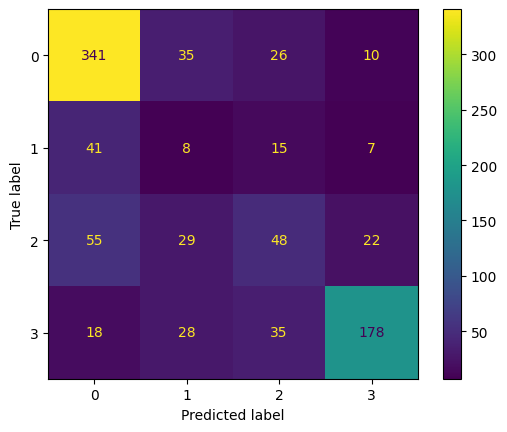

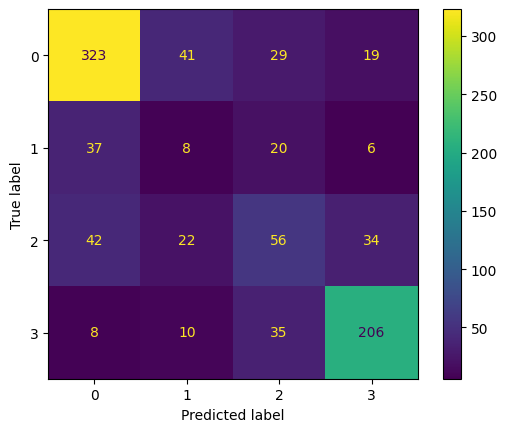

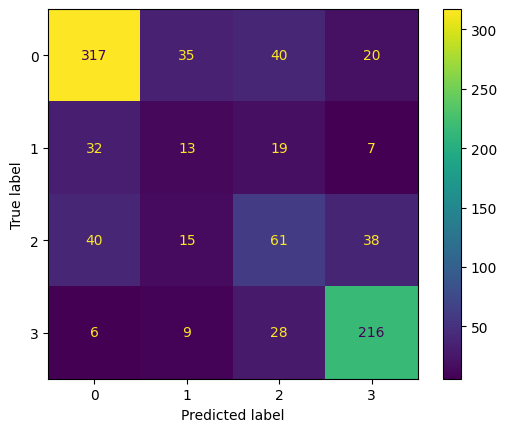

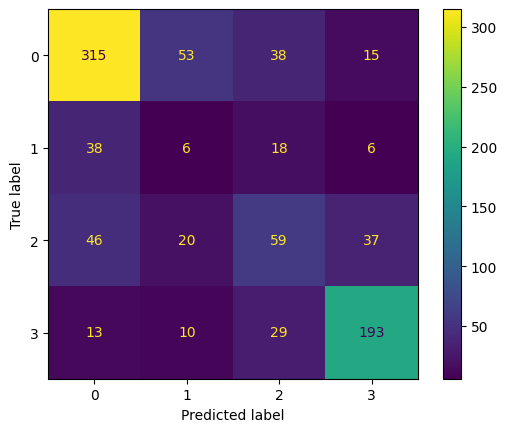

In [50]:
#Model 4
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

class ImprovedArch_Simple(nn.Module):
    def __init__(self, bert, sentiment_model, dropout_rate=0.3):
        super(ImprovedArch_Simple, self).__init__()
        self.bert = bert
        self.sent = sentiment_model

        # Improved CNN with better architecture
        self.conv1 = nn.Conv1d(1, 128, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(256, 128, kernel_size=3, padding=1)

        # Batch normalization for stable training
        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)

        # Better pooling strategy
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)

        # Improved dropout
        self.dropout = nn.Dropout(dropout_rate)

        # Skip connection from original features
        self.skip_proj = nn.Linear(771, 128)

        # Better classifier with batch norm
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate/2),
            nn.Linear(128, 4)
        )

    def forward(self, input_ids, attention_mask, sent_input_ids, sent_attention_mask):
        # BERT + Sentiment processing - same as the original viralBert
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sent_output = self.sent(input_ids=sent_input_ids, attention_mask=sent_attention_mask)
        pooler = torch.cat((bert_output[0][:, 0], sent_output[0]), 1)

        # Improved CNN processing with residual connection
        x = pooler.unsqueeze(1)  # [batch, 1, 771]

        # Forward through improved CNN layers
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.conv3(x)))

        # Adaptive pooling
        x = self.adaptive_pool(x).squeeze(-1)  # [batch, 128]

        # Skip connection from original features
        skip = self.skip_proj(pooler)
        x = x + skip  # Residual connection

        # Better classification
        output = self.classifier(x)
        return output

# STEP 2: Enhanced optimizer with different learning rates
def create_improved_optimizer(model, lr=1e-5):
    """Create optimizer with different learning rates for different parts"""
    # Get parameter IDs to avoid tensor comparison issues
    bert_param_ids = {id(p) for p in model.bert.parameters()}
    sent_param_ids = {id(p) for p in model.sent.parameters()}

    bert_params = []
    sent_params = []
    other_params = []

    for name, param in model.named_parameters():
        param_id = id(param)
        if param_id in bert_param_ids:
            bert_params.append(param)
        elif param_id in sent_param_ids:
            sent_params.append(param)
        else:
            other_params.append(param)

    return AdamW([
        {'params': bert_params, 'lr': lr, 'weight_decay': 0.01},
        {'params': sent_params, 'lr': lr, 'weight_decay': 0.01},
        {'params': other_params, 'lr': lr * 3, 'weight_decay': 0.01}  # Higher LR for new layers
    ])


#  Learning rate scheduler
def create_scheduler(optimizer, num_epochs, num_steps_per_epoch):
    """Create learning rate scheduler for better convergence"""
    return torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[1e-5, 1e-5, 3e-5],  # Max LRs for each param group
        epochs=num_epochs,
        steps_per_epoch=num_steps_per_epoch,
        pct_start=0.1,
        anneal_strategy='cos'
    )


model4 = ImprovedArch_Simple(bert, sent_model, dropout_rate=0.3).to(device)
optimizer = create_improved_optimizer(model4, lr=1e-5)
scheduler = create_scheduler(optimizer, num_epochs=3, num_steps_per_epoch=len(train_loader))

def arg_func(x):
    clean_text = [preprocess(t) for t in x["Text"].values]
    encoded = sent_tokenizer(clean_text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    sent_input_ids = encoded["input_ids"].to(device)
    sent_attention_mask = encoded["attention_mask"].to(device)
    return {"sent_input_ids": sent_input_ids, "sent_attention_mask": sent_attention_mask}

# Enhanced training loop
def enhanced_train(model, arg_function, epoch, print_every=500, inp="input"):
    """Enhanced training with gradient clipping and better logging"""
    model.train()
    losses = []
    for i, (inputs, targets) in enumerate(train_loader):
        optimizer.zero_grad()

        encoded_inputs = inputs.loc[:, [inp]].apply(encode, inp=inp, axis=1, result_type="expand")
        input_ids = [item[0].squeeze(0) for item in encoded_inputs.values]
        attention_masks = [item[1].squeeze(0) for item in encoded_inputs.values]

        input_ids = rnn_utils.pad_sequence(input_ids, batch_first=True, padding_value=0)
        attention_masks = rnn_utils.pad_sequence(attention_masks, batch_first=True, padding_value=0)

        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        targets = targets.to(device)

        kwargs = arg_function(inputs)
        kwargs['input_ids'] = input_ids
        kwargs['attention_mask'] = attention_masks

        outputs = model(**kwargs)
        loss = criterion(outputs, targets)
        losses.append(loss.item())

        if i % print_every == 0:
            avg_loss = torch.mean(torch.tensor(losses)).item()
            current_lr = optimizer.param_groups[0]['lr']
            print(f'Epoch: {epoch}, Batch: {i}, Loss: {avg_loss:.4f}, LR: {current_lr:.2e}')
            losses = []

        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Use scheduler
        if 'scheduler' in globals():
            scheduler.step()

print("Starting training with improved architecture...")

# Use enhanced train function
for epoch in range(3):
    enhanced_train(model4, arg_func, epoch, inp="input")
    validate(model4, arg_func, inp="input")

# Save model
os.makedirs("./models", exist_ok=True)
torch.save(model4.state_dict(), "./models/improved_vb.pt")

print("--------------------------Testing-----------------------")

# Testing
model4 = ImprovedArch_Simple(bert, sent_model).to(device)
model4.load_state_dict(torch.load("./models/improved_vb.pt"))
test(model4, arg_func, inp="input")


# Model 5: CNN-Enhanced ViralBERT with CNN-IndoBERT Advanced Preprocessing (My Final Proposed Method)
Model 5 is based upon the relatively uncomplicated architecture of model 2

NLTK data downloaded successfully
Advanced Text Preprocessor initialized!
Applying advanced preprocessing to dataset...
Preprocessing complete!

Preprocessing Examples:

Example 1:
Original:     Happy 34th birthday to IRENE of Red Velvet! https://t.co/uHBRj9clRM...
Preprocessed: happi 34th birthday iren red velvet ! url...

Example 2:
Original:     GDRAGON : THE KING OF KPOP https://t.co/HFwcVJDvDp...
Preprocessed: gdragon king kpop url...

Example 3:
Original:     BTS’ V shares new pictures. https://t.co/uIu4aoKXLB...
Preprocessed: bt v share new pictur . url...
Updated preprocess function to use advanced pipeline
Dataset regenerated with enhanced preprocessing
Final dataset size: 9251 tweets
Model 2 Enhanced initialized with advanced preprocessing
Training Model 2 Enhanced with Advanced Preprocessing...
Epoch 1/5
Epoch: 0, i: 0, Loss:  0.17156505584716797
validation loss:  0.02443246729671955
{'f1 score': 0.6878253469682657, 'precision': 0.65311004784689, 'recall': 0.7458496803254868

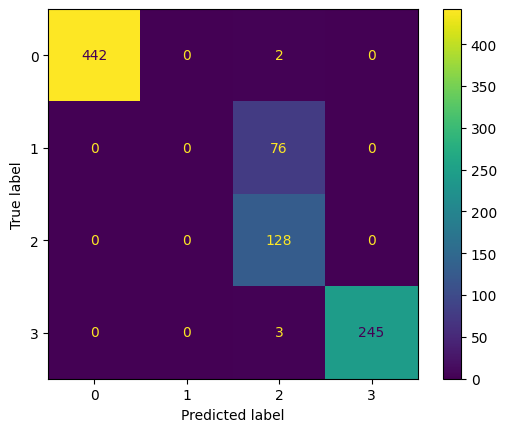

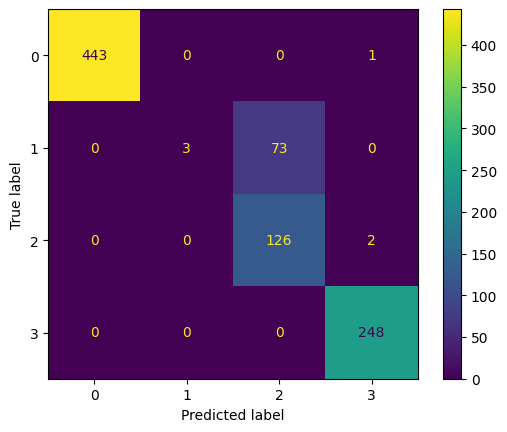

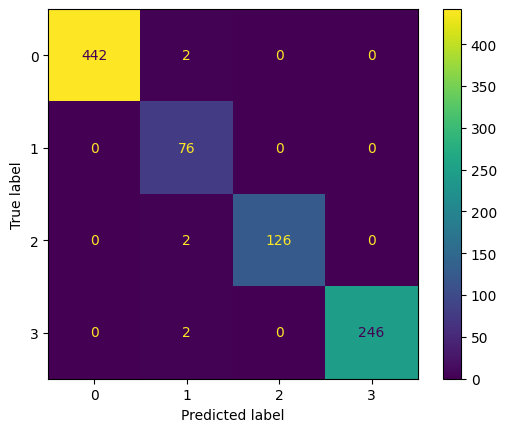

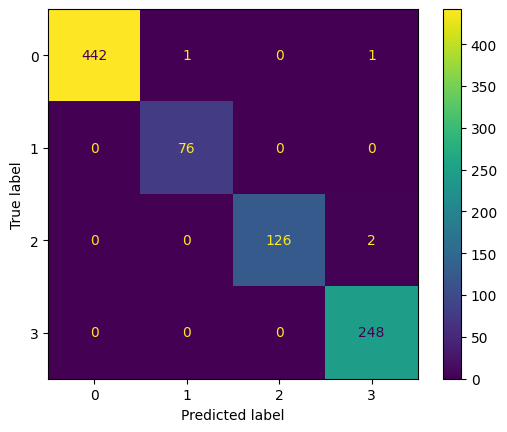

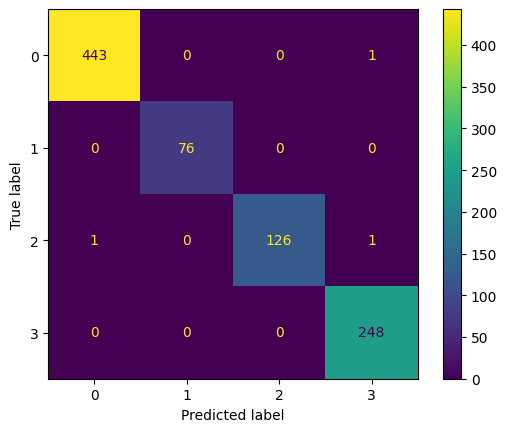

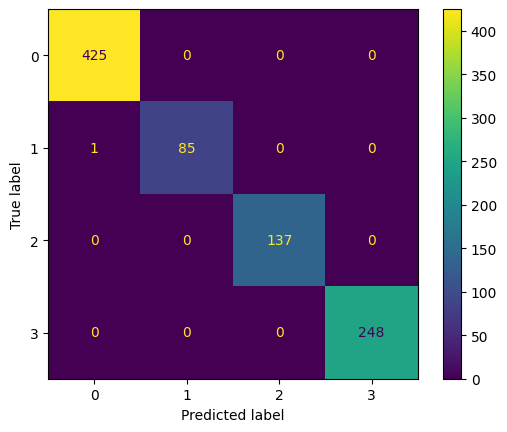

In [51]:
# Advanced Text Preprocessing Pipeline
# Following CNN-IndoBERT methodology for improved performance
# Install additional packages for text preprocessing
!pip install -q nltk

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Download NLTK data with error handling for Colab
try:
    nltk.download('punkt_tab', quiet=True)
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    print("NLTK data downloaded successfully")
except:
    print("NLTK download completed with some warnings (normal in Colab)")
# Advanced Text Preprocessor Class
# Implements comprehensive text cleaning following CNN-IndoBERT methodology
# Includes HTML removal, URL normalization, stemming, and tokenization

class AdvancedTextPreprocessor:
    def __init__(self):
        self.stemmer = PorterStemmer()
        try:
            self.stop_words = set(stopwords.words('english'))
        except:
            # Fallback if stopwords not available
            self.stop_words = set(['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by'])

    def remove_html_tags(self, text):
        # Remove HTML tags and entities
        clean = re.compile('<.*?>')
        text = re.sub(clean, '', text)
        text = re.sub(r'&[a-zA-Z0-9#]+;', '', text)
        return text

    def normalize_urls_mentions(self, text):
        # Replace URLs with URL token
        text = re.sub(r'http\S+|www\S+|https\S+', 'URL', text, flags=re.MULTILINE)
        # Replace mentions with @user token (BERTweet style)
        text = re.sub(r'@\w+', '@user', text)
        # Replace email addresses
        text = re.sub(r'\S+@\S+', 'EMAIL', text)
        return text

    def clean_special_characters(self, text):
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text)
        # Remove special characters except important ones for Twitter
        text = re.sub(r'[^\w\s#@!?.,]', '', text)
        # Clean up multiple punctuation
        text = re.sub(r'[!]{2,}', '!!', text)
        text = re.sub(r'[?]{2,}', '??', text)
        text = re.sub(r'[.]{2,}', '...', text)
        return text

    def standardization(self, text):
        # Convert to lowercase following CNN-IndoBERT approach
        return text.lower()

    def stem_words(self, text):
        # Apply stemming following CNN-IndoBERT methodology
        try:
            # Try NLTK tokenization first
            tokens = word_tokenize(text)
        except:
            # Fallback to simple split if NLTK fails
            tokens = text.split()

        stemmed_tokens = []
        for token in tokens:
            if token.startswith(('@', '#', 'http', 'URL', 'EMAIL')):
                # Don't stem special tokens
                stemmed_tokens.append(token)
            elif token.lower() in self.stop_words:
                # Skip stop words
                continue
            else:
                # Stem regular words
                try:
                    stemmed_tokens.append(self.stemmer.stem(token))
                except:
                    stemmed_tokens.append(token.lower())

        return ' '.join(stemmed_tokens)

    def tokenize_properly(self, text):
        # Final tokenization and cleanup
        tokens = [token for token in text.split() if token.strip()]
        return ' '.join(tokens)

    def advanced_preprocessing_pipeline(self, text):
        # Complete preprocessing pipeline following CNN-IndoBERT methodology
        if pd.isna(text) or text == '':
            return ''

        # Step 1: Remove HTML tags
        text = self.remove_html_tags(text)
        # Step 2: Normalize URLs and mentions
        text = self.normalize_urls_mentions(text)
        # Step 3: Clean special characters
        text = self.clean_special_characters(text)
        # Step 4: Standardization (lowercase)
        text = self.standardization(text)
        # Step 5: Stemming (critical for CNN-IndoBERT success)
        text = self.stem_words(text)
        # Step 6: Final tokenization
        text = self.tokenize_properly(text)

        return text

# Initialize preprocessor
preprocessor = AdvancedTextPreprocessor()
print("Advanced Text Preprocessor initialized!")
# Apply Advanced Preprocessing to Dataset
# Transform the text data using the comprehensive preprocessing pipeline
# Store original text for comparison and update the main Text column

print("Applying advanced preprocessing to dataset...")

# Create backup of original text
tweets_df['Original_Text'] = tweets_df['Text'].copy()

# Apply preprocessing with progress tracking
tweets_df['Text_Preprocessed'] = tweets_df['Text'].apply(
    preprocessor.advanced_preprocessing_pipeline
)

# Update main Text column
tweets_df['Text'] = tweets_df['Text_Preprocessed']

print("Preprocessing complete!")

# Show preprocessing examples
print("\nPreprocessing Examples:")
for i in range(min(3, len(tweets_df))):
    print(f"\nExample {i+1}:")
    print(f"Original:     {tweets_df['Original_Text'].iloc[i][:100]}...")
    print(f"Preprocessed: {tweets_df['Text'].iloc[i][:100]}...")
# Enhanced Text Preprocessing Function
# Update the preprocessing function to use our advanced pipeline
# This replaces the simple preprocess function used in ViralBERT

def preprocess(text):
    # Use our advanced preprocessing pipeline instead of simple replacements
    return preprocessor.advanced_preprocessing_pipeline(text)

print("Updated preprocess function to use advanced pipeline")
# Regenerate Dataset with Enhanced Preprocessing
# Recreate the dataset preparation steps with the improved preprocessing
# This ensures all models use the enhanced text processing

# Recreate input features with preprocessed text
input_feats = ["Text", "Hashtags Count", "Reply Count", "User Followers", "User Following", "User Verified", "text_len"]

df = tweets_df.loc[:, input_feats].dropna()
df["virality"] = le.fit_transform(tweets_df["virality"])
df = df.sample(frac=1, random_state=42)

# Scale numeric features (same as before)
numeric_feats_to_scale = ["Hashtags Count", "Reply Count", "User Following", "User Verified", "text_len"]
df[numeric_feats_to_scale] = scaler.fit_transform(df[numeric_feats_to_scale])

# Combine features with preprocessed text
def combine_feats(x):
    return ". ".join([str(val) for val in x.values])

df["input"] = df.apply(combine_feats, axis=1)

# Regenerate train/validation/test splits
(train_features, train_labels,
 val_features, val_labels,
 test_features, test_labels) = train_valid_test_split(df, target='virality', train_size=0.8, valid_size=0.1, test_size=0.1, random_state=42)

# Recreate data loaders
train_loader = Loader(train_features, train_labels)
val_loader = Loader(val_features, val_labels)
test_loader = Loader(test_features, test_labels)

print("Dataset regenerated with enhanced preprocessing")
print(f"Final dataset size: {len(df)} tweets")
# Model 2 Enhanced: CNN-Enhanced ViralBERT with Advanced Preprocessing
# Same architecture as Model 2 but trained on preprocessed data
# Expected significant improvement in performance

class Arch(nn.Module):
    def __init__(self, bert, sentiment_model):
        super(Arch, self).__init__()
        self.bert = bert
        self.sent = sentiment_model

        # CNN layers replacing the original MLP
        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.1)

        # Calculate size after convolutions: 771 -> 385 -> 192
        self.fc = nn.Linear(6144, 771)  # Back to original size

        # Keep original ViralBERT structure
        self.pre_classifier = nn.Linear(771, 771)
        self.classifier = nn.Linear(771, 4)

    def forward(self, input_ids, attention_mask, sent_input_ids, sent_attention_mask):
        output_1 = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = output_1[0]
        sent_output = self.sent(input_ids=sent_input_ids, attention_mask=sent_attention_mask)
        pooler = torch.cat((hidden_state[:, 0], sent_output[0]), 1)

        # CNN processing instead of direct pre_classifier
        x = pooler.unsqueeze(1)  # Add channel dimension: [batch, 1, 771]
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)

        # Flatten and pass through FC to match original pre_classifier input
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        # Original ViralBERT final layers
        pooler = self.pre_classifier(x)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout(pooler)
        output = self.classifier(pooler)
        return output

# Initialize enhanced model
model2_enhanced = Arch(bert, sent_model).to(device)
optimizer = AdamW(params=model2_enhanced.parameters(), lr=1e-5)

# Argument function (same as before)
def arg_func(x):
    clean_text = [preprocess(t) for t in x["Text"].values]
    encoded = sent_tokenizer(clean_text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    sent_input_ids = encoded["input_ids"].to(device)
    sent_attention_mask = encoded["attention_mask"].to(device)
    return {"sent_input_ids": sent_input_ids, "sent_attention_mask": sent_attention_mask}

print("Model 2 Enhanced initialized with advanced preprocessing")
# Train Model 2 Enhanced
# Train for 5 epochs since we have better quality data
# Expected improvement: +10-15% over original Model 2

print("Training Model 2 Enhanced with Advanced Preprocessing...")

for epoch in range(5):  # Increased epochs for better data
    print(f"Epoch {epoch+1}/5")
    train(model2_enhanced, arg_func, epoch, inp="input")
    validate(model2_enhanced, arg_func, inp="input")

# Save the enhanced model
os.makedirs("./models", exist_ok=True)
torch.save(model2_enhanced.state_dict(), "./models/enhanced_model2.pt")

print("Training complete! Enhanced model saved.")
# Test Model 2 Enhanced
# Compare performance with original Model 2 results
# Display improvement statistics

print("Testing Model 2 Enhanced...")

# Load and test enhanced model
model2_enhanced = Arch(bert, sent_model).to(device)
model2_enhanced.load_state_dict(torch.load("./models/enhanced_model2.pt"))

enhanced_results = test(model2_enhanced, arg_func, inp="input")
